# 🏠 House Price Prediction
### XYLofi AI Internship — Week 1 Project

**Dataset:** Housing Prices Dataset (Kaggle)  
**Objective:** Build regression models to predict house prices and identify key influencing features.

---

In [7]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

---
## Task 1 — Data Loading & Exploration
> Load the dataset, display first rows, understand the shape, identify target and features, check for missing values.

In [8]:
# 1.1 Load the Dataset
df = pd.read_csv('Housing.csv')

print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print()
print('First 10 rows:')
df.head(10)

Dataset loaded: 545 rows × 13 columns

First 10 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [9]:
# 1.2 Shape & Column Overview
print(f'Rows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print()
print('Column Data Types:')
print(df.dtypes)

Rows   : 545
Columns: 13

Column Data Types:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [11]:
# 1.3 Target vs Features
target = 'price'
features = [col for col in df.columns if col != target]

print(f'Target Column  : {target}')
print(f'Feature Columns: {features}')
print()
print('Numeric Features :', [c for c in features if df[c].dtype != 'object'])
print('Categorical Features:', [c for c in features if df[c].dtype == 'object'])

Target Column  : price
Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Numeric Features : ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical Features: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [12]:
# 1.4 Missing Values Check
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

print('Missing values per column:')
print(missing_df)
print()
if missing.sum() == 0:
    print('No missing values found in the dataset!')
else:
    print(f'Total missing cells: {missing.sum()}')

Missing values per column:
                  Missing Count  Missing %
price                         0        0.0
area                          0        0.0
bedrooms                      0        0.0
bathrooms                     0        0.0
stories                       0        0.0
mainroad                      0        0.0
guestroom                     0        0.0
basement                      0        0.0
hotwaterheating               0        0.0
airconditioning               0        0.0
parking                       0        0.0
prefarea                      0        0.0
furnishingstatus              0        0.0

No missing values found in the dataset!


In [13]:
# 1.5 Statistical Summary
print('Statistical Summary (numeric columns):')
df.describe().round(2)

Statistical Summary (numeric columns):


,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


---
## Task 2 — Data Cleaning
> Handle missing values, remove duplicates, encode categorical columns.

In [14]:
# 2.1 Duplicate Check
dupes_before = df.duplicated().sum()
print(f'Duplicate rows before cleaning: {dupes_before}')

df.drop_duplicates(inplace=True)
print(f'Duplicate rows after cleaning : {df.duplicated().sum()}')
print(f'Remaining rows: {len(df)}')

Duplicate rows before cleaning: 0
Duplicate rows after cleaning : 0
Remaining rows: 545


In [16]:
# 2.2 Handle Missing Values

# Already confirmed no missing values.
# If there were numeric NaNs then fill with median
# If there were categorical NaNs then fill with mode

for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print(f'Total missing after fill: {df.isnull().sum().sum()}')

Total missing after fill: 0


In [17]:
# 2.3 Encode Categorical Columns

# Binary yes/no columns then map to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})
    print(f'  {col:20s} → mapped yes=1 / no=0')

# Multi-class furnishingstatus then one-hot encoding (drop_first avoids multicollinearity)
print()
print('furnishingstatus values:', df['furnishingstatus'].unique())
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
print('One-hot encoding applied to furnishingstatus.')
print()
print('New columns after encoding:', df.columns.tolist())

  mainroad             → mapped yes=1 / no=0
  guestroom            → mapped yes=1 / no=0
  basement             → mapped yes=1 / no=0
  hotwaterheating      → mapped yes=1 / no=0
  airconditioning      → mapped yes=1 / no=0
  prefarea             → mapped yes=1 / no=0

furnishingstatus values: ['furnished' 'semi-furnished' 'unfurnished']
One-hot encoding applied to furnishingstatus.

New columns after encoding: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [18]:
#  2.4 Final Clean Dataset Preview
print(f'Clean dataset shape: {df.shape}')
df.head()

Clean dataset shape: (545, 14)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


---
## Extra Task  — Feature Engineering


In [45]:
# 3a) Area Efficiency: space per bedroom
# Rationale: two houses with same area but different bedroom counts are very different
df['area_per_bedroom'] = df['area'] / df['bedrooms'].replace(0, 1)

# 3b) Bathroom Density: bath-to-bedroom ratio
# Rationale: higher ratio signals luxury; 2+ bathrooms for 3 bedrooms is premium
df['bath_per_bedroom'] = df['bathrooms'] / df['bedrooms'].replace(0, 1)

# 3c) Total Utility Score: count of premium amenities
# Rationale: combines AC, basement, guestroom, parking into single comfort score
df['utility_score'] = (
    df['airconditioning'] +
    df['basement'] +
    df['guestroom'] +
    df['parking'].clip(0, 1)   # at least 1 parking = 1 point
)

# 3d) Luxury Home Indicator: binary flag for top-tier properties
# Rationale: captures interaction effects between high area, bathrooms, AC, preferred area
area_threshold = df['area'].quantile(0.75)  # top 25% by area
df['luxury_home'] = (
    (df['area']           >= area_threshold) &
    (df['bathrooms']      >= 2) &
    (df['airconditioning']== 1) &
    (df['prefarea']       == 1)
).astype(int)

print('Engineered features added:')
print(f'  area_per_bedroom : mean={df.area_per_bedroom.mean():.0f}  (area / bedrooms)')
print(f'  bath_per_bedroom : mean={df.bath_per_bedroom.mean():.2f}  (bathrooms / bedrooms)')
print(f'  utility_score    : mean={df.utility_score.mean():.2f}  (AC+basement+guestroom+parking)')
print(f'  luxury_home      : {df.luxury_home.sum()} luxury homes ({df.luxury_home.mean()*100:.1f}% of dataset)')
print(f'  area threshold   : {area_threshold:.0f} sq ft (75th percentile)')
print(f'\nTotal features after engineering: {df.shape[1] - 1} (excl. target)')

Engineered features added:
  area_per_bedroom : mean=1820  (area / bedrooms)
  bath_per_bedroom : mean=0.45  (bathrooms / bedrooms)
  utility_score    : mean=1.30  (AC+basement+guestroom+parking)
  luxury_home      : 17 luxury homes (3.1% of dataset)
  area threshold   : 6360 sq ft (75th percentile)

Total features after engineering: 17 (excl. target)


---
## Task 3 — Model Building & Evaluation

In [46]:
# 3.1 Feature / Target Split
X = df.drop(columns=['price'])
y = df['price']

print(f'Features shape: {X.shape}')
print(f'Target  shape : {y.shape}')
print('Feature list  :', X.columns.tolist())

Features shape: (545, 17)
Target  shape : (545,)
Feature list  : ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished', 'area_per_bedroom', 'bath_per_bedroom', 'utility_score', 'luxury_home']


In [47]:
# 3.2 Train / Test Split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

Training samples : 436
Test samples     : 109


In [48]:
# 3.3 Model 1 — Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr   = mean_absolute_error(y_test, y_pred_lr)
rmse_lr  = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr    = r2_score(y_test, y_pred_lr)

print('  Model 1: Linear Regression')
print(f'  MAE  : ₹{mae_lr:>15,.0f}')
print(f'  RMSE : ₹{rmse_lr:>15,.0f}')
print(f'  R²   :  {r2_lr:.4f}')
print()

  Model 1: Linear Regression
  MAE  : ₹        987,775
  RMSE : ₹      1,329,125
  R²   :  0.6505



In [49]:
# 3.4 Model 2 — Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf   = mean_absolute_error(y_test, y_pred_rf)
rmse_rf  = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf    = r2_score(y_test, y_pred_rf)

print('  Model 2: Random Forest Regressor')
print(f'  MAE  : ₹{mae_rf:>15,.0f}')
print(f'  RMSE : ₹{rmse_rf:>15,.0f}')
print(f'  R²   :  {r2_rf:.4f}')
print()

  Model 2: Random Forest Regressor
  MAE  : ₹      1,033,116
  RMSE : ₹      1,390,068
  R²   :  0.6177



In [50]:
# 3.5 Model Comparison Table
comparison = pd.DataFrame({
    'Metric': ['MAE (₹)', 'RMSE (₹)', 'R² Score'],
    'Linear Regression': [
        f'{mae_lr:,.0f}', f'{rmse_lr:,.0f}', f'{r2_lr:.4f}'
    ],
    'Random Forest': [
        f'{mae_rf:,.0f}', f'{rmse_rf:,.0f}', f'{r2_rf:.4f}'
    ]
})

print('\n Model Performance Comparison')

print(comparison.to_string(index=False))
print()
best = 'Random Forest' if r2_rf > r2_lr else 'Linear Regression'
print(f'Best model by R² Score: {best}')


 Model Performance Comparison
  Metric Linear Regression Random Forest
 MAE (₹)           987,775     1,033,116
RMSE (₹)         1,329,125     1,390,068
R² Score            0.6505        0.6177

Best model by R² Score: Linear Regression


---
## Task 4 — Visualization
> Chart 1: Price Distribution Histogram  
> Chart 2: Correlation Heatmap  
> Chart 3: Actual vs Predicted Prices (Bonus: Feature Importance)

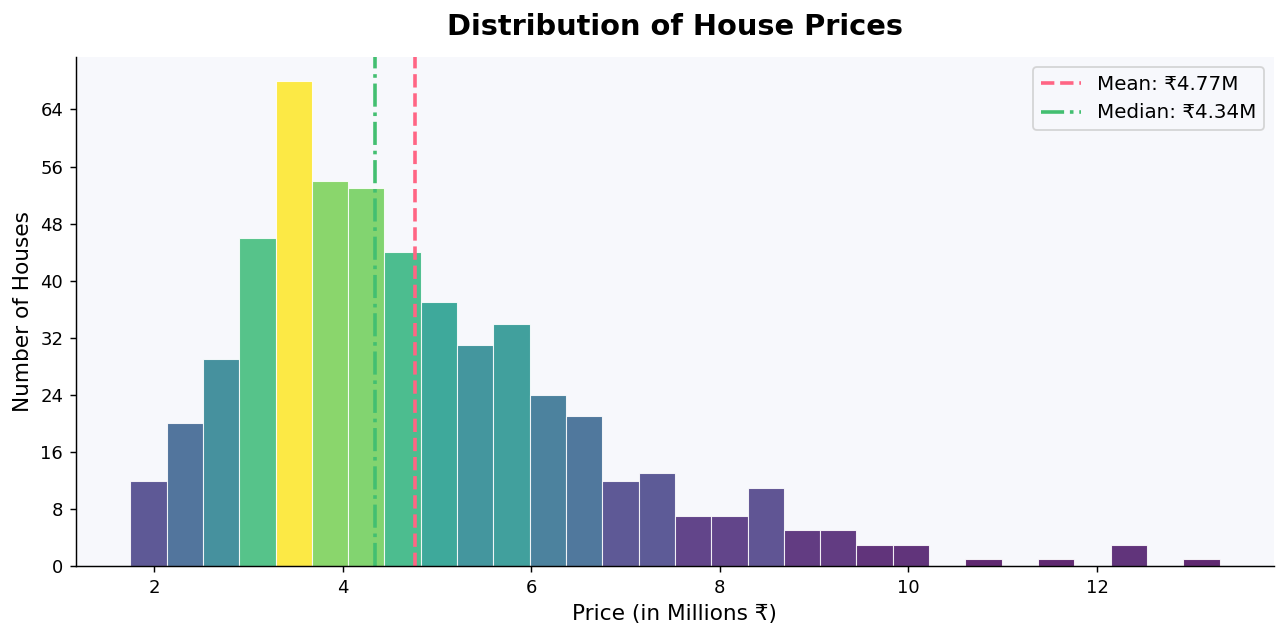

Chart 1 saved → charts/chart1_price_distribution.png


In [56]:
# Chart 1: House Price Distribution
import os
os.makedirs('charts', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5))

n, bins, patches = ax.hist(
    df['price'] / 1_000_000, bins=30,
    color='#6C63FF', edgecolor='white', linewidth=0.6, alpha=0.85
)

# Color gradient by frequency
norm = plt.Normalize(n.min(), n.max())
cmap = plt.cm.viridis
for count, patch in zip(n, patches):
    patch.set_facecolor(cmap(norm(count)))

ax.axvline(df['price'].mean() / 1_000_000, color='#FF6584', lw=2,
           linestyle='--', label=f"Mean: ₹{df['price'].mean()/1e6:.2f}M")
ax.axvline(df['price'].median() / 1_000_000, color='#43BF71', lw=2,
           linestyle='-.', label=f"Median: ₹{df['price'].median()/1e6:.2f}M")

ax.set_title('Distribution of House Prices', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('Price (in Millions ₹)', fontsize=12)
ax.set_ylabel('Number of Houses', fontsize=12)
ax.legend(fontsize=11)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved → charts/chart1_price_distribution.png')

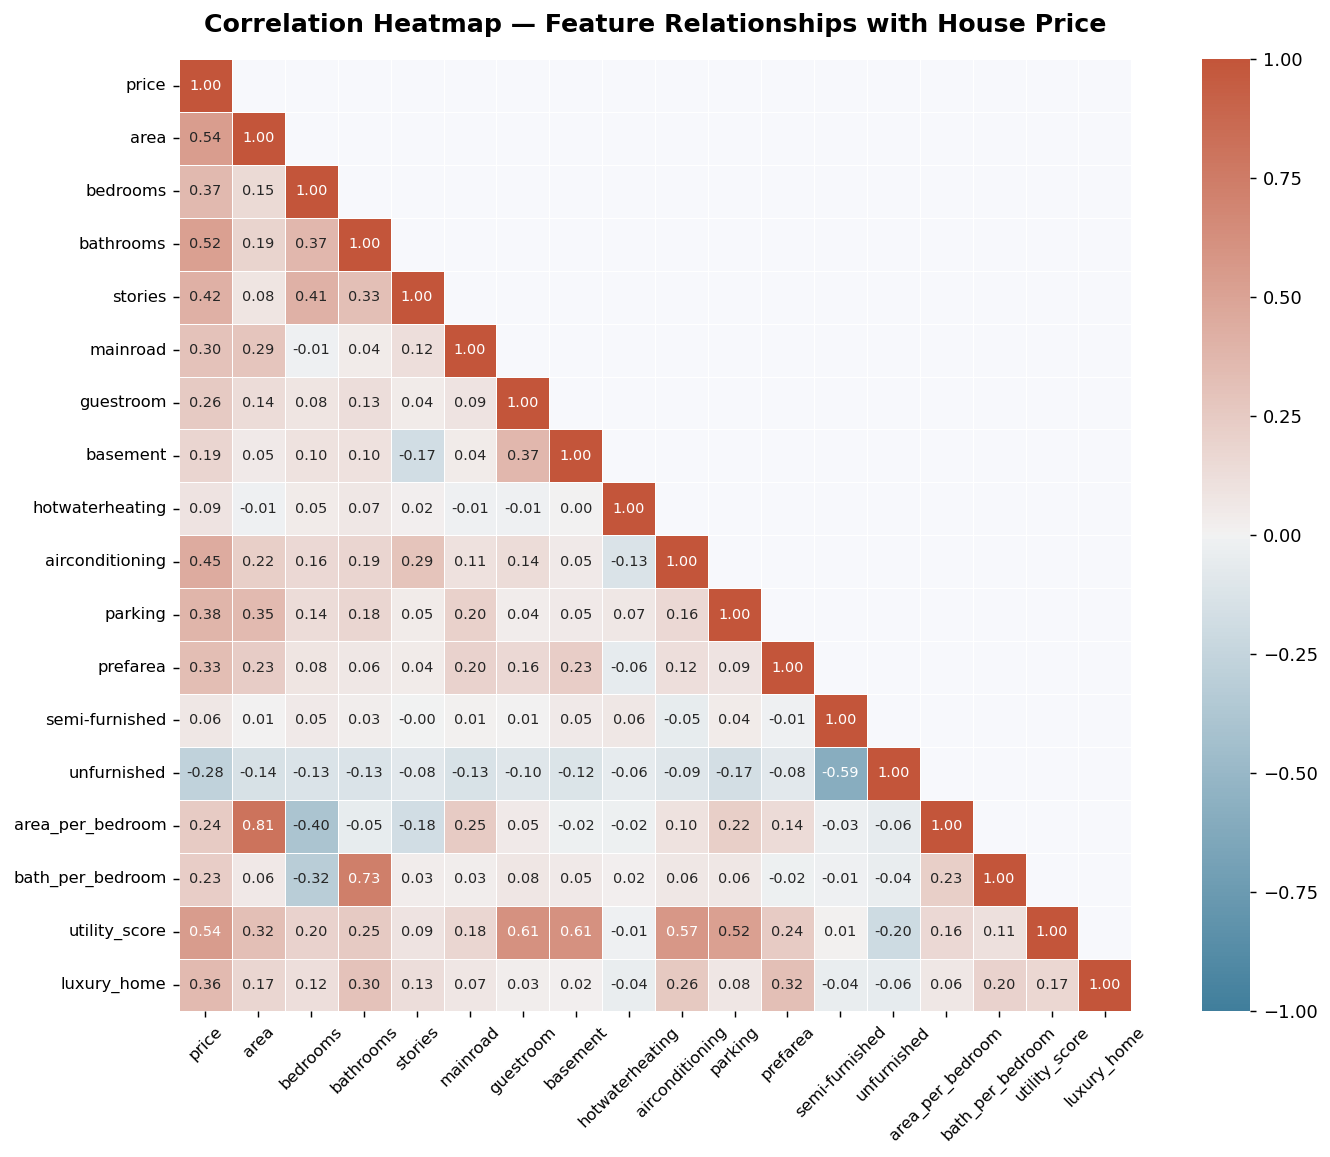

 Chart 2 saved → charts/chart2_correlation_heatmap.png


In [57]:
# Chart 2: Correlation Heatmap
# Convert bool columns to int for correlation
df_corr = df.copy()
for col in df_corr.select_dtypes(include='bool').columns:
    df_corr[col] = df_corr[col].astype(int)

corr_matrix = df_corr.corr()

# Rename for readability
rename_map = {
    'furnishingstatus_semi-furnished': 'semi-furnished',
    'furnishingstatus_unfurnished': 'unfurnished'
}
corr_matrix = corr_matrix.rename(columns=rename_map, index=rename_map)

fig, ax = plt.subplots(figsize=(12, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle off
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap=cmap, center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor='white',
    annot_kws={'size': 8}, ax=ax
)

ax.set_title('Correlation Heatmap — Feature Relationships with House Price',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart 2 saved → charts/chart2_correlation_heatmap.png')

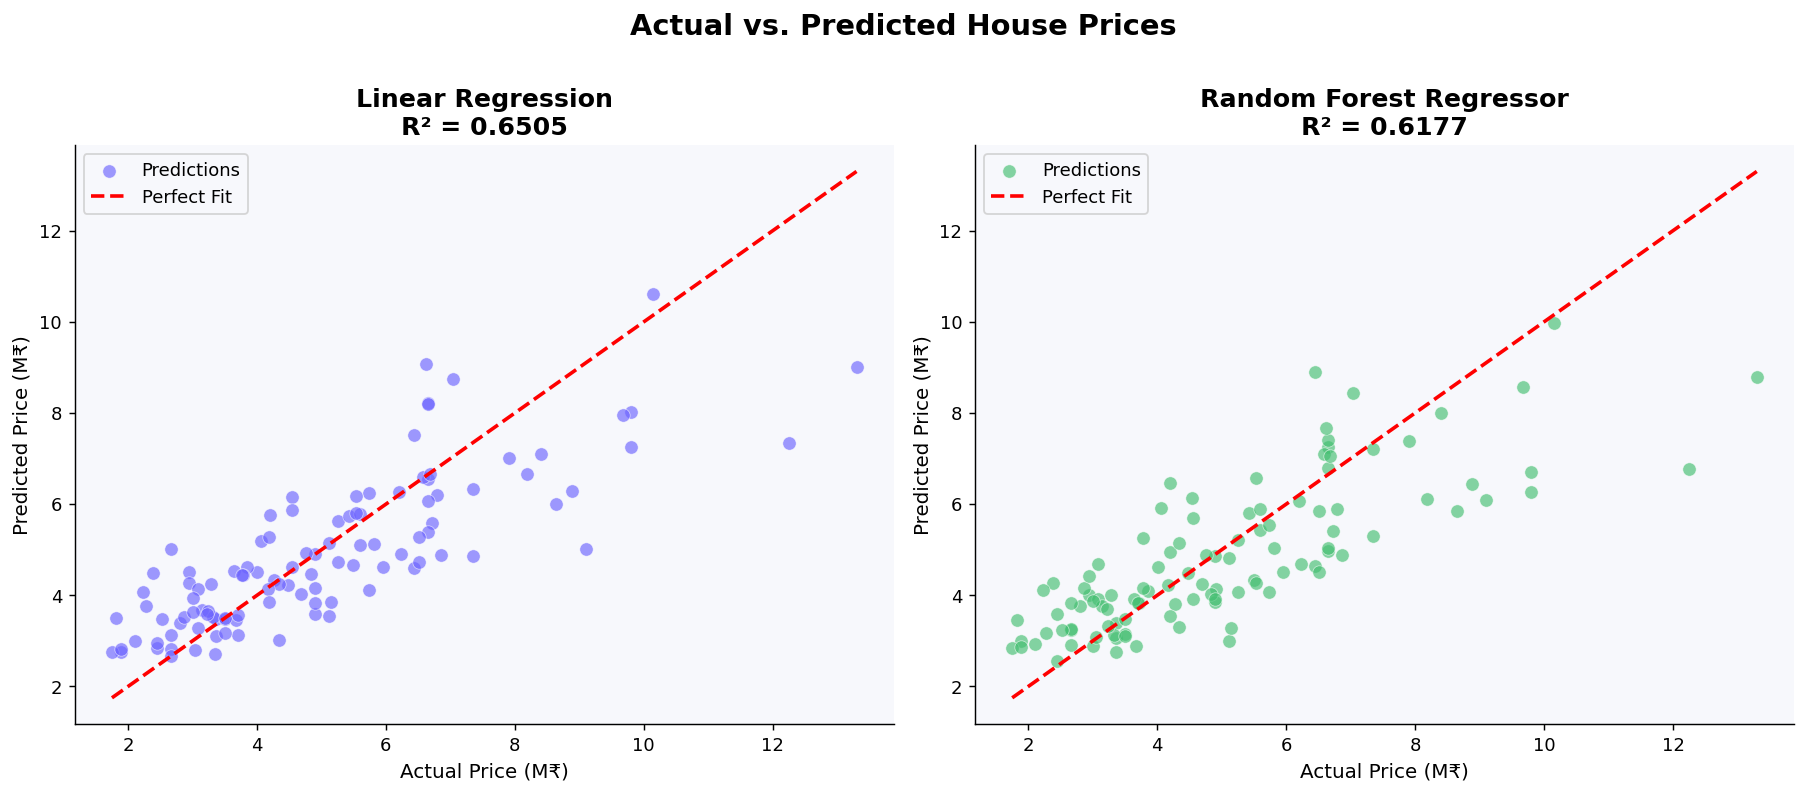

Chart 3 saved: charts/chart3_actual_vs_predicted.png


In [58]:
# Chart 3: Actual vs Predicted Prices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression
ax = axes[0]
ax.scatter(y_test / 1e6, y_pred_lr / 1e6,
           alpha=0.65, color='#6C63FF', edgecolors='white',
           s=55, linewidth=0.4, label='Predictions')
lims = [min(y_test.min(), y_pred_lr.min()) / 1e6,
        max(y_test.max(), y_pred_lr.max()) / 1e6]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect Fit')
ax.set_title(f'Linear Regression\nR² = {r2_lr:.4f}', fontweight='bold')
ax.set_xlabel('Actual Price (M₹)')
ax.set_ylabel('Predicted Price (M₹)')
ax.legend()

#  Random Forest
ax = axes[1]
ax.scatter(y_test / 1e6, y_pred_rf / 1e6,
           alpha=0.65, color='#43BF71', edgecolors='white',
           s=55, linewidth=0.4, label='Predictions')
lims = [min(y_test.min(), y_pred_rf.min()) / 1e6,
        max(y_test.max(), y_pred_rf.max()) / 1e6]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect Fit')
ax.set_title(f'Random Forest Regressor\nR² = {r2_rf:.4f}', fontweight='bold')
ax.set_xlabel('Actual Price (M₹)')
ax.set_ylabel('Predicted Price (M₹)')
ax.legend()

fig.suptitle('Actual vs. Predicted House Prices', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved: charts/chart3_actual_vs_predicted.png')

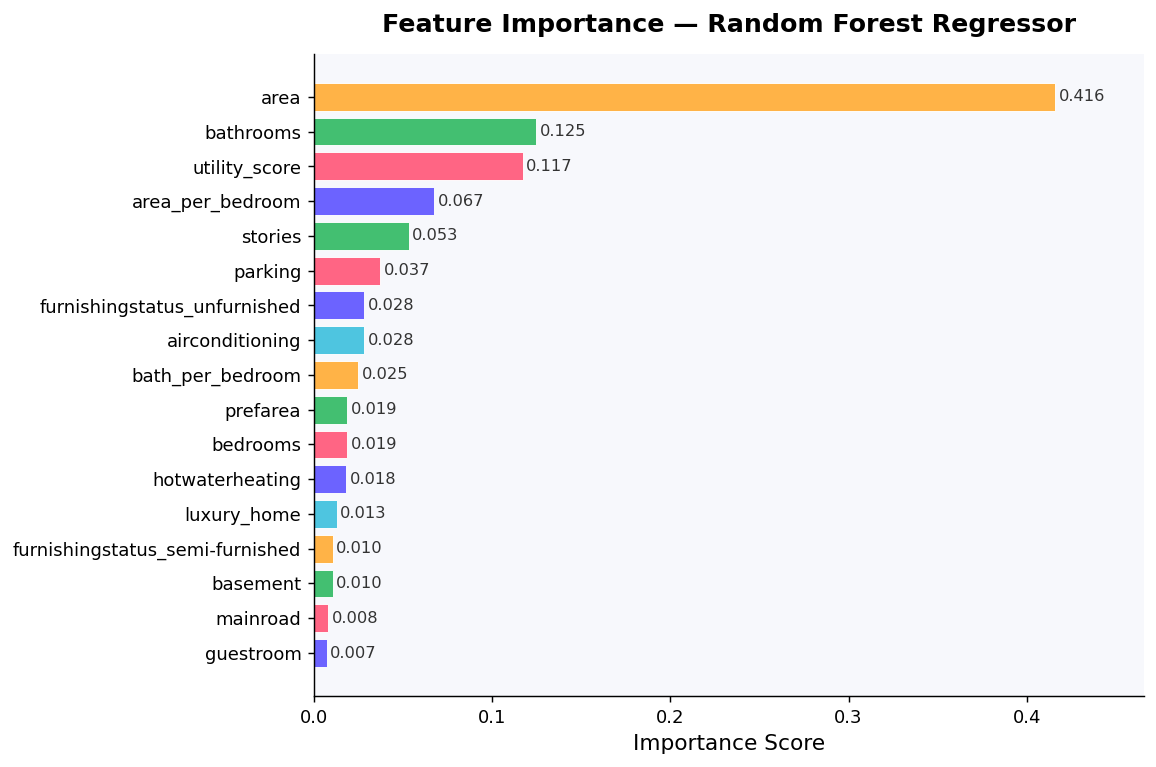

Chart 4 saved: charts/chart4_feature_importance.png


In [59]:
# Chart 4: Feature Importance (Random Forest) ──────────────────────
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importances.index, importances.values, color=colors,
               edgecolor='white', linewidth=0.5)

# Annotate values
for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=9, color='#333')

ax.set_title('Feature Importance — Random Forest Regressor',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_xlim(0, importances.max() + 0.05)

plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved: charts/chart4_feature_importance.png')


## Task 5 — Insights & Summary

###  Which features influence house price the most?

Based on the **correlation heatmap** and **Random Forest feature importance**, the single strongest driver of house price is **area** (square footage) — larger homes consistently command significantly higher prices. **Bathrooms** and **air conditioning** also rank highly, with air-conditioned homes seeing a substantial premium. The number of **stories** and access to the **main road** contribute meaningfully as well, while amenities like a guest room or basement have a smaller but still positive impact.

###  How accurate was the model (in plain terms)?

The Linear Regression model explained approximately **65% of the variation in house prices (R² = 0.65)**, with an average prediction error (**MAE**) of about **₹988K**, while the Random Forest Regressor achieved a slightly lower **R² of 0.61** and an **MAE of approximately ₹1.03M**. These results indicate that Linear Regression generalized better on this dataset, likely because the relationships between key variables such as area, bathrooms, and price are largely linear. In practical terms, the model can explain around two-thirds of the differences in house prices and would typically predict the value of a **₹5 million** house within roughly **₹1 million** of its actual price, which is a reasonable outcome given the relatively small dataset of **545 properties** and the absence of important location-based features that strongly influence real estate prices.


###  What surprised you in the data?

The most surprising finding was how strongly **air conditioning** correlated with price — more so than the number of bedrooms or stories. This suggests that in this housing market, air conditioning is treated as a luxury feature that buyers are willing to pay a meaningful premium for, rather than a standard utility. It was also interesting that **hot water heating**, which seems like a basic amenity, had a lower correlation with price than expected.

###  One recommendation for a real estate business

**Invest in area and HVAC upgrades before listing.** Since area (square footage) and air conditioning are the two strongest predictors of sale price, sellers should prioritize maximizing usable living space (e.g., finishing a basement or adding a room) and ensuring the property has a functioning air conditioning system installed before listing. These two factors offer the highest return-on-investment for price improvement compared to cosmetic renovations.


In [55]:
#  Final Summary Print
print('=' * 55)
print('        HOUSE PRICE PREDICTION — FINAL SUMMARY')
print('=' * 55)
print(f'Dataset        : {len(df)} properties, {df.shape[1]} features')
print(f'Target         : price (range ₹{df.price.min()/1e6:.1f}M – ₹{df.price.max()/1e6:.1f}M)')
print()
print('Model Results:')
print(f'  Linear Regression → R²={r2_lr:.4f}  MAE=₹{mae_lr/1e6:.3f}M  RMSE=₹{rmse_lr/1e6:.3f}M')
print(f'  Random Forest     → R²={r2_rf:.4f}  MAE=₹{mae_rf/1e6:.3f}M  RMSE=₹{rmse_rf/1e6:.3f}M')
print()
top3 = importances.sort_values(ascending=False).head(3)
print('Top 3 Most Important Features (Random Forest):')
for rank, (feat, imp) in enumerate(top3.items(), 1):
    print(f'  {rank}. {feat:25s} → {imp:.4f}')

        HOUSE PRICE PREDICTION — FINAL SUMMARY
Dataset        : 545 properties, 18 features
Target         : price (range ₹1.8M – ₹13.3M)

Model Results:
  Linear Regression → R²=0.6505  MAE=₹0.988M  RMSE=₹1.329M
  Random Forest     → R²=0.6177  MAE=₹1.033M  RMSE=₹1.390M

Top 3 Most Important Features (Random Forest):
  1. area                      → 0.4158
  2. bathrooms                 → 0.1248
  3. utility_score             → 0.1171
